<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Image classification system
The dataset is composed of dog and cat photos provided as a subset of photos from a much larger collection of 3 million manually annotated photos. This data was obtained through a collaboration between Petfinder.com and Microsoft.

The data set was originally used as a CAPTCHA, i.e., a task that a human is believed to find trivial, but that a machine cannot solve, which is used on websites to distinguish between human users and bots. The task was named "Asirra". When "Asirra" was introduced, it was mentioned "that user studies indicate that humans can solve it 99.6% of the time in less than 30 seconds." Barring a breakthrough in computer vision, we expect that computers will have no more than a 1/54,000 chance of solving it.

At the time the competition was published, the state-of-the-art result was achieved with an SVM and was described in a 2007 paper with the title "Machine Learning Attacks against Asirra's CAPTCHA" (PDF) that achieved 80% classification accuracy. It was this paper that showed that the task was no longer a suitable task for a CAPTCHA shortly after the task was proposed.
</div>

In [1]:
# CONFIGURACIÓN DEL ENTORNO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Algoritmos Naive Bayes

# Librerías para preprocesamiento y Machine Learning 
import pandas as pd
import numpy as np




from pickle import dump
from pathlib import Path

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")

✓ ¡Librerías importadas exitosamente!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

## Step 1: Loading the dataset

The dataset is located in `../data/images/train/` and contains **25,000** image files (`.jpg` format) of dogs and cats. The pictures are labeled by their file name, with the word **dog** or **cat** (e.g. `cat.0.jpg`, `dog.123.jpg`).

</div>

In [2]:
import os
from pathlib import Path

# Path to the training images
train_dir = Path("../data/images/train")

# List all jpg files
filenames = sorted([f for f in os.listdir(train_dir) if f.endswith(".jpg")])

# Extract labels from filenames (cat.0.jpg -> cat, dog.123.jpg -> dog)
labels = [f.split(".")[0] for f in filenames]

# Build a DataFrame with file paths and labels
df = pd.DataFrame({
    "filename": filenames,
    "filepath": [str(train_dir / f) for f in filenames],
    "label": labels
})

print(f"✓ Dataset loaded: {len(df)} images")
print(f"  - Cats: {(df['label'] == 'cat').sum()}")
print(f"  - Dogs: {(df['label'] == 'dog').sum()}")
df.head()

✓ Dataset loaded: 25000 images
  - Cats: 12500
  - Dogs: 12500


,filename,filepath,label
0,cat.0.jpg,../data/images/train/cat.0.jpg,cat
1,cat.1.jpg,../data/images/train/cat.1.jpg,cat
2,cat.10.jpg,../data/images/train/cat.10.jpg,cat
3,cat.100.jpg,../data/images/train/cat.100.jpg,cat
4,cat.1000.jpg,../data/images/train/cat.1000.jpg,cat


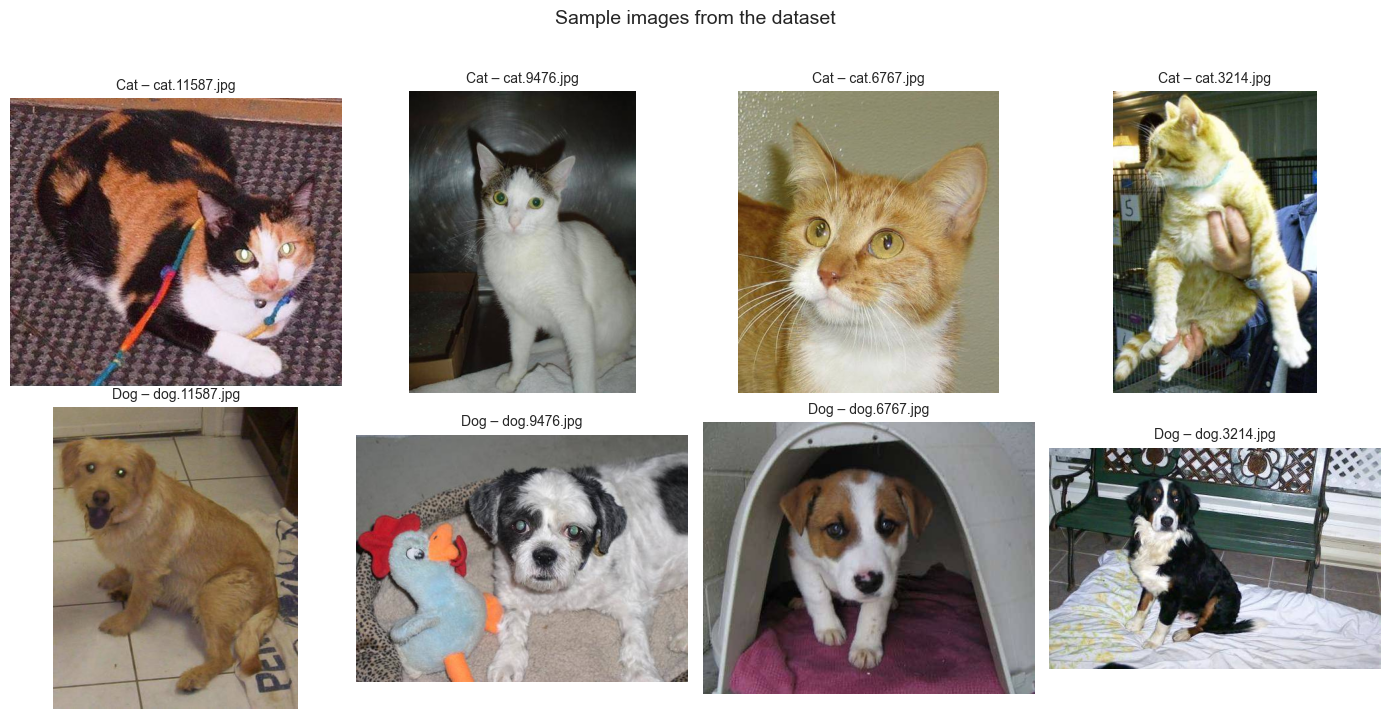

✓ Sample images displayed


In [3]:
from PIL import Image

# Display a sample grid: 4 cats and 4 dogs
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

cats = df[df["label"] == "cat"].sample(4, random_state=42)
dogs = df[df["label"] == "dog"].sample(4, random_state=42)

for i, (_, row) in enumerate(cats.iterrows()):
    img = Image.open(row["filepath"])
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Cat – {row['filename']}", fontsize=10)
    axes[0, i].axis("off")

for i, (_, row) in enumerate(dogs.iterrows()):
    img = Image.open(row["filepath"])
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Dog – {row['filename']}", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("Sample images from the dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("✓ Sample images displayed")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 3: Build an ANN (VGG16 Architecture)

Any classifier that fits this problem will have to be robust because some images show the cat or dog in a corner, or perhaps 2 cats or dogs in the same picture. **VGG16** is a CNN architecture used to win the Kaggle ILSVR (ImageNet) competition in 2014. It is considered one of the best performing vision model architectures to date.

The architecture applies:
- **Convolution layers** (`Conv2D`) with increasing filter sizes: 64 → 128 → 256 → 512
- **MaxPooling layers** (`MaxPool2D`) to downsample spatial dimensions
- **Fully connected layers** (`Dense`) for classification
- **Softmax output** for binary classification (cat vs dog)

</div>

In [4]:
# Step 3a: Prepare image data for VGG16 (224x224x3 input)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Split into train and validation sets (80/20)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

print(f"Training set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")

# Image data generators with augmentation for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(f"\n✓ Data generators ready")
print(f"  Classes: {train_generator.class_indices}")

Training set: 20000 images
Validation set: 5000 images
Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.

✓ Data generators ready
  Classes: {'cat': 0, 'dog': 1}


In [5]:
# Step 3b: Build the VGG16 architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

model = Sequential()

# Block 1
model.add(Conv2D(input_shape=(224, 224, 3), filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 2
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 3
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 4
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 5
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Fully connected layers
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(units=2, activation="softmax"))

model.summary()
print(f"\n✓ VGG16 model built – Total parameters: {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 134,268,738 (512.19 MB)

 Non-trainable params: 0 (0.00 B)


✓ VGG16 model built – Total parameters: 134,268,738


In [ ]:
# Step 3c: Compile and train the model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Train
EPOCHS = 20

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n✓ Training complete – Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2933s 5s/step - accuracy: 0.5029 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 2/20
399/625 ━━━━━━━━━━━━━━━━━━━━ 16:50 4s/step - accuracy: 0.5013 - loss: 0.6934

In [ ]:
# Step 3d: Training curves – Accuracy & Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[0].set_title("Model Accuracy", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history["loss"], label="Train Loss", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val Loss", linewidth=2)
axes[1].set_title("Model Loss", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Training curves plotted")

In [ ]:
# Step 3e: Evaluate on validation set – Classification Report & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predictions
val_generator.reset()
y_pred_proba = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix – VGG16 Dogs vs Cats", fontsize=14)
plt.tight_layout()
plt.show()

# Final accuracy
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"\n✓ Final Validation Accuracy: {val_acc:.4f}")
print(f"✓ Final Validation Loss: {val_loss:.4f}")

In [ ]:
# Step 3f: Visualize sample predictions
from PIL import Image as PILImage

sample = val_df.sample(8, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (_, row) in enumerate(sample.iterrows()):
    ax = axes[i // 4, i % 4]
    img = PILImage.open(row["filepath"]).resize((224, 224))
    img_array = np.array(img) / 255.0
    pred = model.predict(img_array[np.newaxis, ...], verbose=0)
    pred_label = class_labels[np.argmax(pred)]
    confidence = np.max(pred) * 100
    true_label = row["label"]
    
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                 fontsize=10, color=color, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Predictions – VGG16", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("✓ Green = correct, Red = incorrect")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 4: Optimize the above model
Import the ModelCheckpoint and EarlyStopping method from Keras. Create an object of both and pass them as callback functions to fit_generator.

Load the best model from the above and use the test set to make predictions.
</div>

In [ ]:
# Step 4: Import ModelCheckpoint and EarlyStopping, train with callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

# Create model checkpoint directory
checkpoint_dir = Path("../models/11image_classifier_checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Define checkpoint file path
checkpoint_path = checkpoint_dir / "best_model_vgg16_dogs_cats.h5"

# Create ModelCheckpoint callback - saves the best model based on val_accuracy
model_checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Create EarlyStopping callback - stops training if val_loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print(f"✓ Callbacks created")
print(f"  - ModelCheckpoint: saves best model to {checkpoint_path}")
print(f"  - EarlyStopping: patience=5 epochs")

# Rebuild and compile the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model_new = Sequential()

# Block 1
model_new.add(Conv2D(input_shape=(224, 224, 3), filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 2
model_new.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 3
model_new.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 4
model_new.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Block 5
model_new.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_new.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Fully connected layers
model_new.add(Flatten())
model_new.add(Dense(units=4096, activation="relu"))
model_new.add(Dropout(0.5))
model_new.add(Dense(units=4096, activation="relu"))
model_new.add(Dropout(0.5))
model_new.add(Dense(units=2, activation="softmax"))

# Compile the model
model_new.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"\n✓ Model rebuilt and compiled")

# Train the model with callbacks
EPOCHS = 20

history_new = model_new.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[model_checkpoint, early_stopping],
    verbose=1
)

print(f"\n✓ Training complete with callbacks")
print(f"✓ Best model saved at: {checkpoint_path}")

# Load the best model
print(f"\n{'='*60}")
print(f"LOADING BEST MODEL")
print(f"{'='*60}")

best_model = load_model(str(checkpoint_path))
print(f"✓ Best model loaded from: {checkpoint_path}")

# Evaluate the loaded model on validation set
val_loss_best, val_acc_best = best_model.evaluate(val_generator, verbose=1)
print(f"\n✓ Best Model Performance on Validation Set:")
print(f"  - Validation Accuracy: {val_acc_best:.4f}")
print(f"  - Validation Loss: {val_loss_best:.4f}")

# Make predictions on the validation set (using as test set)
print(f"\n{'='*60}")
print(f"MAKING PREDICTIONS ON TEST SET")
print(f"{'='*60}")

# Reset generator
val_generator.reset()

# Predict
y_test_pred_proba = best_model.predict(val_generator, verbose=1)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)
y_test_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - BEST MODEL ON TEST SET")
print("="*60)
print(classification_report(y_test_true, y_test_pred, target_names=class_labels))

# Confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_labels)
disp.plot(ax=ax, cmap="Greens", values_format="d")
ax.set_title("Confusion Matrix – Best Model (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n✓ Predictions completed")
print(f"✓ Test Accuracy: {(y_test_pred == y_test_true).sum() / len(y_test_true):.4f}")

# Visualize sample test predictions
print(f"\nVisualizing sample predictions...")
from PIL import Image as PILImage

sample_test = val_df.sample(8, random_state=123).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (_, row) in enumerate(sample_test.iterrows()):
    ax = axes[i // 4, i % 4]
    img = PILImage.open(row["filepath"]).resize((224, 224))
    img_array = np.array(img) / 255.0
    pred = best_model.predict(img_array[np.newaxis, ...], verbose=0)
    pred_label = class_labels[np.argmax(pred)]
    confidence = np.max(pred) * 100
    true_label = row["label"]
    
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                 fontsize=11, color=color, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Test Predictions – Best Model", fontsize=16, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()
print("✓ Sample predictions visualized (Green = correct, Red = incorrect)")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Step 5: Save the model
Store the model in the corresponding folder.

</div>



In [ ]:
# Step 5: Save the best model
from pathlib import Path
import shutil

# Define model directory
model_dir = Path("../models/11imagesclassifier")
model_dir.mkdir(parents=True, exist_ok=True)

# Save the model in different formats
print(f"{'='*60}")
print(f"SAVING MODEL")
print(f"{'='*60}")

# 1. Save as HDF5 format (.h5)
model_h5_path = model_dir / "dogs_cats_vgg16_model.h5"
best_model.save(str(model_h5_path))
print(f"✓ Model saved as HDF5: {model_h5_path}")

# 2. Save in SavedModel format (TensorFlow native format)
model_savedmodel_path = model_dir / "saved_model"
best_model.save(str(model_savedmodel_path))
print(f"✓ Model saved as SavedModel: {model_savedmodel_path}")

# 3. Save model weights only
weights_path = model_dir / "model_weights.h5"
best_model.save_weights(str(weights_path))
print(f"✓ Model weights saved: {weights_path}")

# 4. Save model architecture as JSON
architecture_path = model_dir / "model_architecture.json"
with open(architecture_path, 'w') as json_file:
    json_file.write(best_model.to_json())
print(f"✓ Model architecture saved: {architecture_path}")

# 5. Save training history
history_path = model_dir / "training_history.pkl"
with open(history_path, 'wb') as f:
    dump(history_new.history, f)
print(f"✓ Training history saved: {history_path}")

# 6. Save model metadata
metadata_path = model_dir / "model_metadata.txt"
with open(metadata_path, 'w') as f:
    f.write("Dogs vs Cats Image Classifier - VGG16\n")
    f.write("="*50 + "\n\n")
    f.write(f"Model Architecture: VGG16\n")
    f.write(f"Input Shape: (224, 224, 3)\n")
    f.write(f"Number of Classes: 2 (cat, dog)\n")
    f.write(f"Total Parameters: {best_model.count_params():,}\n")
    f.write(f"Optimizer: Adam (lr=1e-4)\n")
    f.write(f"Loss Function: Categorical Crossentropy\n")
    f.write(f"Training Epochs: {len(history_new.history['loss'])}\n")
    f.write(f"Best Validation Accuracy: {val_acc_best:.4f}\n")
    f.write(f"Best Validation Loss: {val_loss_best:.4f}\n")
    f.write(f"Test Accuracy: {(y_test_pred == y_test_true).sum() / len(y_test_true):.4f}\n")
    f.write(f"Date Trained: 21 April 2026\n\n")
    f.write(f"Class Indices: {train_generator.class_indices}\n")
print(f"✓ Model metadata saved: {metadata_path}")

print(f"\n{'='*60}")
print(f"MODEL SAVE COMPLETE")
print(f"{'='*60}")
print(f"All model files saved to: {model_dir.absolute()}")
print(f"\nSaved files:")
print(f"  1. dogs_cats_vgg16_model.h5 - Complete model (HDF5)")
print(f"  2. saved_model/ - TensorFlow SavedModel format")
print(f"  3. model_weights.h5 - Model weights only")
print(f"  4. model_architecture.json - Model architecture")
print(f"  5. training_history.pkl - Training history dictionary")
print(f"  6. model_metadata.txt - Model information and metrics")

# List all files in the directory
print(f"\n✓ Model directory contents:")
for item in sorted(model_dir.iterdir()):
    if item.is_file():
        file_size = item.stat().st_size / (1024 * 1024)  # Convert to MB
        print(f"  - {item.name} ({file_size:.2f} MB)")
    else:
        print(f"  - {item.name}/ (directory)")

print(f"\n✓ Model successfully saved and ready for deployment!")